# Plot stratospheric ozone

In [1]:
# === Import ===
import warnings 
warnings.filterwarnings('ignore')
import os
import cf_units
import numpy as np
import xarray as xr
import regionmask
from scipy import stats
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
import matplotlib.colors as colors
from matplotlib.gridspec import GridSpec

In [2]:
# === Processing functions ===
def adjust_longitude(dataset: xr.Dataset) -> xr.Dataset:
        """Swaps longitude coordinates from range (0, 360) to (-180, 180)
        Args:
            dataset (xr.Dataset): xarray Dataset
        Returns:
            xr.Dataset: xarray Dataset with swapped longitude dimensions
        """
        lon_name = "lon"  # whatever name is in the data

        # Adjust lon values to make sure they are within (-180, 180)
        dataset["_longitude_adjusted"] = xr.where(
            dataset[lon_name] > 180, dataset[lon_name] - 360, dataset[lon_name])
        dataset = (
            dataset.swap_dims({lon_name: "_longitude_adjusted"})
            .sel(**{"_longitude_adjusted": sorted(dataset._longitude_adjusted)})
            .drop_vars(lon_name)
        )

        dataset = dataset.rename({"_longitude_adjusted": lon_name})
        return dataset


# === Figure sizing ===
def autosize_figure(nrows, ncolumns, scale_factor=1, xscale_factor=1, yscale_factor=1):
    xwidth = (ncolumns+0.67) * 5.0 * scale_factor * xscale_factor
    ylength = (nrows+0.67) * 3.6 * scale_factor * yscale_factor
    return (xwidth, ylength)


# === Removing ocean ===
def land_filter(da):
    # Load in land fraction dataset
    land_110 = regionmask.defined_regions.natural_earth_v4_1_0.land_110
    da = da.where(land_110.mask_3D(da).squeeze())
    return da

In [3]:
# === Concatenate ensemble members ===
def merge_ensembles(VAR_DIR, VAR, land_mask=False):
    """ land_filter=True allows for the land filter function to remove the ocean """
    ARISE_ens = []
    SSP245_ens = []

    for ens_num in range(1, 11):
        ARISE_ens.append(xr.open_dataarray(f"{VAR_DIR}{VAR}_CESM2_ARISE_{ens_num:02d}_203501-206912.nc"))
        SSP245_ens.append(xr.open_dataarray(f"{VAR_DIR}{VAR}_CESM2_SSP245_{ens_num:02d}_202001-206912.nc"))

    arise_da = xr.concat(ARISE_ens, dim=xr.DataArray(np.arange(1, len(ARISE_ens)+1), dims="ensemble", name="ensemble"))
    ssp245_da = xr.concat(SSP245_ens, dim=xr.DataArray(np.arange(1, len(SSP245_ens)+1), dims="ensemble", name="ensemble"))

    if land_mask is True:
        print("Filtering ocean")
        arise_da = land_filter(arise_da)
        ssp245_da = land_filter(ssp245_da)

    return arise_da, ssp245_da

## Load and process data

In [4]:
# === Path config ===
O3_DIR = "/glade/work/awells/air_quality/CESM/O3/"

# === Main loop ===
arise_o3, ssp245_o3 = merge_ensembles(O3_DIR, "O3", land_mask=False)

Calculate time, longitude average and ensemble mean

In [5]:
ssp245_early = ssp245_o3.sel(time=slice("2020", "2039")).mean(dim=('time', 'lon', 'ensemble'))
ssp245_late = ssp245_o3.sel(time=slice("2050", "2069")).mean(dim=('time', 'lon', 'ensemble'))
arise = arise_o3.sel(time=slice("2050", "2069")).mean(dim=('time', 'lon', 'ensemble'))

## Calculate statistical significance

In [6]:
# === Stats functions ===
def process_da_for_stats(da, start_year, end_year):
    da_r = da.sel(time=slice(start_year, end_year)).sel(ensemble=1)
    for i in range(2, len(da.ensemble)+1):
        da_ens = da.sel(time=slice(start_year, end_year)).sel(ensemble=i)
        da_r = xr.concat((da_r, da_ens), dim="time")
    return da_r


def stat_sig(da1, da2):
    # For latitude, pressure plots
    stat, pval = stats.ttest_ind(da1.mean("lon"), da2.mean("lon"))
    pval_da = xr.DataArray(data=pval,
                           dims=["lev", "lat"],
                           coords=dict(lat=(["lat"], da1.lat.values),
                                       lev=(["lev"], da1.lev.values)))
    return pval_da

In [7]:
ssp245_early_r = process_da_for_stats(ssp245_o3, "2020", "2039")
ssp245_late_r = process_da_for_stats(ssp245_o3, "2050", "2069")
arise_r = process_da_for_stats(arise_o3, "2050", "2069")

In [8]:
ssp245_late_pval = stat_sig(ssp245_late_r, ssp245_early_r)
arise_early_pval = stat_sig(arise_r, ssp245_early_r)
arise_late_pval = stat_sig(arise_r, ssp245_late_r)

## Load and process tropopause data

In [9]:
# file path
TROP_DIR = "/glade/work/awells/air_quality/CESM/TROP_P/"

# === Main loop ===
arise_trop, ssp245_trop = merge_ensembles(TROP_DIR, "TROP_P", land_mask=False)

Calculate end of century average and ensemble mean

In [10]:
ssp245_t_early = ssp245_trop.sel(time=slice("2020", "2039")).mean(dim=('time', 'lon', 'ensemble'))
ssp245_t_late = ssp245_trop.sel(time=slice("2050", "2069")).mean(dim=('time', 'lon', 'ensemble'))
arise_t = arise_trop.sel(time=slice("2050", "2069")).mean(dim=('time', 'lon', 'ensemble'))

## Calculate percentage difference (245)

In [11]:
ssp245_diff = ssp245_late - ssp245_early
arise_diff = arise - ssp245_early
arise2_diff = arise - ssp245_late

In [12]:
ssp245_perc = (ssp245_diff / ssp245_late) * 100
arise_perc = (arise_diff / arise) * 100
arise2_perc = (arise2_diff / arise) * 100

## Plotting

In [13]:
params = {'legend.fontsize': 35,
          'axes.labelsize': 35,
          'axes.titlesize': 20,
          'axes.linewidth': 8,
          'xtick.labelsize': 35,
          'ytick.labelsize': 15,
          'xtick.major.size': 8,
          'ytick.major.size': 8,
          'axes.grid': True}

plt.rcParams.update(params)

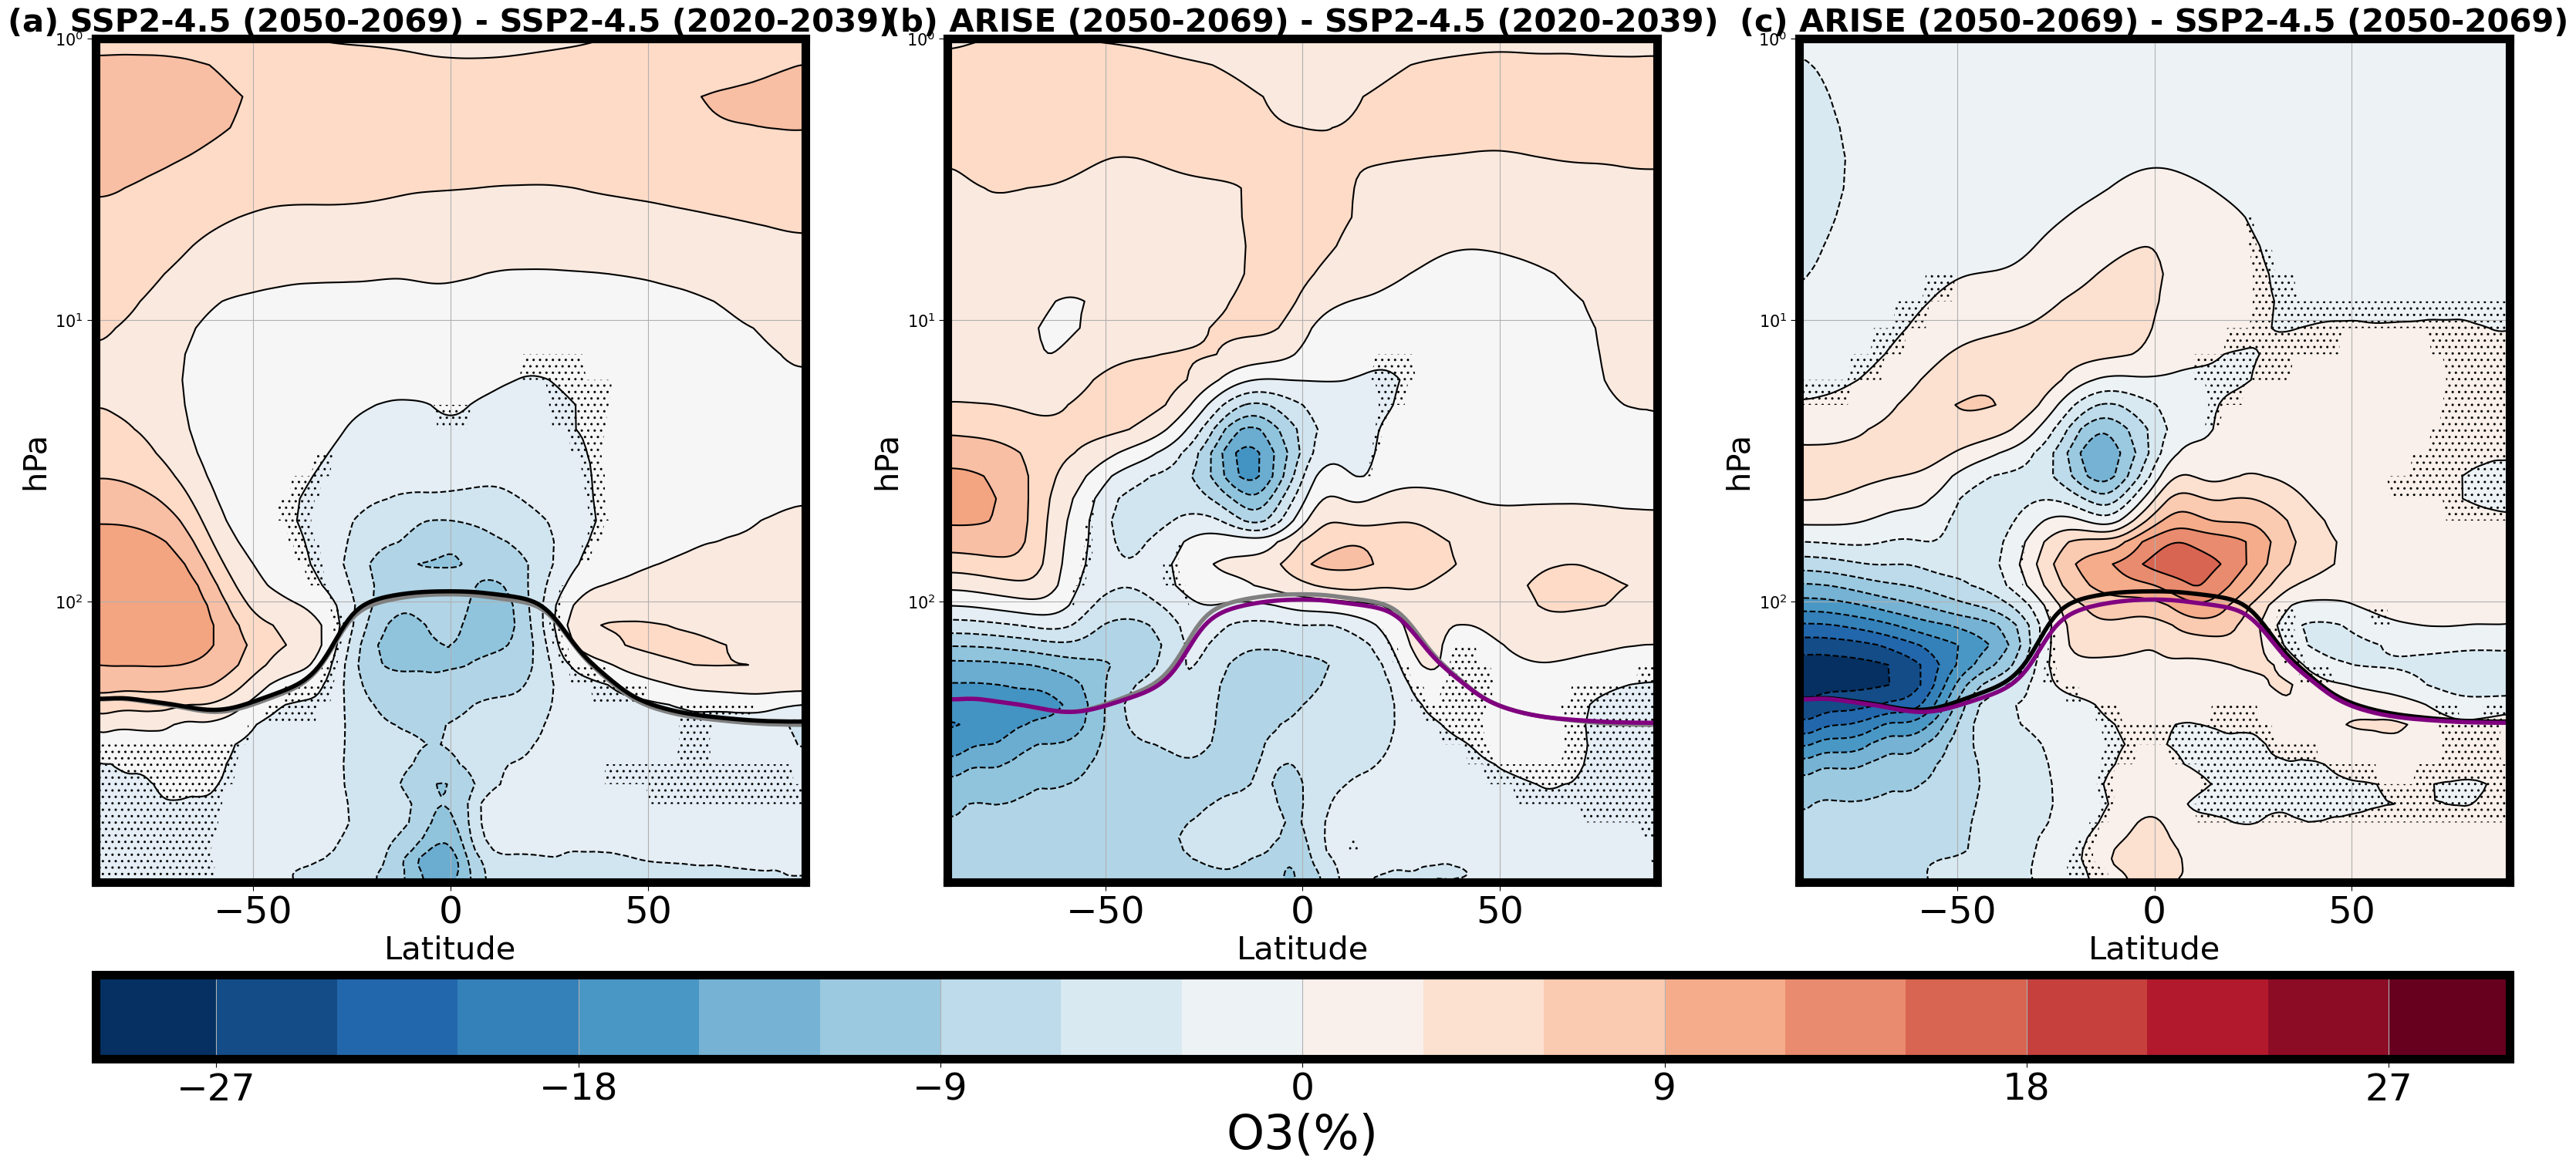

In [23]:
fig = plt.figure(figsize=autosize_figure(1, 3, scale_factor=2.2, yscale_factor=1.3))
gs = GridSpec(2, 3, height_ratios=[10, 1])

col_map = mpl_cm.get_cmap('RdBu_r')
lvs = np.linspace(-30, 30, 21)
norm = colors.BoundaryNorm(lvs, col_map.N)

ax1 = fig.add_subplot(gs[0, 0])
ssp245_perc.plot.contourf(levels=lvs, cmap=col_map, add_colorbar=False)
ssp245_perc.plot.contour(levels=lvs, colors='k')
(ssp245_t_early/100).plot(color='grey', linewidth=4)
(ssp245_t_late/100).plot(color='k', linewidth=4)
ssp245_late_pval.where(ssp245_late_pval > 0.05).plot.contourf(colors='none', levels=[0,1], hatches=['..'], add_colorbar=False)
ax1.invert_yaxis()
ax1.set_ylim([ssp245_early.lev.max(), 1])
ax1.set_yscale('log')
plt.ylabel('hPa', fontsize=30)
plt.xlabel('Latitude', fontsize=30)
plt.title('(a) SSP2-4.5 (2050-2069) - SSP2-4.5 (2020-2039)', fontweight='bold', fontsize=30)

ax2 = fig.add_subplot(gs[0, 1])
arise_perc.plot.contourf(levels=lvs, cmap=col_map, add_colorbar=False)
arise_perc.plot.contour(levels=lvs, colors='k')
(ssp245_t_early/100).plot(color='grey', linewidth=4)
(arise_t/100).plot(color='purple', linewidth=4)
arise_early_pval.where(arise_early_pval > 0.05).plot.contourf(colors='none', levels=[0,1], hatches=['..'], add_colorbar=False)
ax2.invert_yaxis()
ax2.set_ylim([ssp245_early.lev.max(), 1])
ax2.set_yscale('log')
plt.ylabel('hPa', fontsize=30)
plt.xlabel('Latitude', fontsize=30)
plt.title('(b) ARISE (2050-2069) - SSP2-4.5 (2020-2039)', fontweight='bold', fontsize=30)

ax3 = fig.add_subplot(gs[0, 2])
cb = arise2_perc.plot.contourf(levels=lvs, cmap=col_map, add_colorbar=False)
arise2_perc.plot.contour(levels=lvs, colors='k')
(ssp245_t_late/100).plot(color='k', linewidth=4)
(arise_t/100).plot(color='purple', linewidth=4)
arise_late_pval.where(arise_late_pval > 0.05).plot.contourf(colors='none', levels=[0,1], hatches=['..'], add_colorbar=False)
ax3.invert_yaxis()
ax3.set_ylim([ssp245_early.lev.max(), 1])
ax3.set_yscale('log')
plt.ylabel('hPa', fontsize=30)
plt.xlabel('Latitude', fontsize=30)
plt.title('(c) ARISE (2050-2069) - SSP2-4.5 (2050-2069)', fontweight='bold', fontsize=30)

ax4 = fig.add_subplot(gs[1, :])
col_bar = plt.colorbar(cb, cax=ax4, orientation='horizontal')
col_bar.set_label('O3(%)', fontsize=45)